# DMQ Hyperparameter Tuning with Optuna

This notebook is designed to experimentally tune the DMQ model using Optuna. The process is as follows:

1.  **Data Preparation**: Load the data and split it into a training set (up to Dec 1997) and a test set (Jan 1998 - Dec 2024).
2.  **Evaluation Metrics**: Define R-squared for mean forecasts and quantile loss for quantile forecasts.
3.  **Optuna Study**: Define an objective function for Optuna to search for the best hyperparameters.
4.  **Analysis**: Analyze the results of the best trial and visualize the forecasts.

## 1. Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import optuna
from operator import itemgetter

from keras.callbacks import EarlyStopping
from sklearn.metrics import r2_score

from src.preprocessing.prepare_quantile_data import prepare_quantile_data
from src.train.models import build_dmq_v0
from src.train.losses import quantile_loss
from src.utils.evaluation import compute_oos_r1_score, compute_oos_r2_score, estimate_mean_from_quantiles
from src.train.tuning import CVObjective

import yaml

with open("./config/config.yaml", "r") as f:
    config = yaml.safe_load(f)

c:\Users\Robpr\Documents\projects\macroatrisk\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Data Preparation

In [2]:
target_path = './data/processed/us_4q_fred_y.parquet'
input_paths = ['./data/processed/us_4q_fred_x.parquet']

# Prepare data (including RNN sequences)
non_rnn_data, rnn_data, meta_data = prepare_quantile_data(
    target=0,
    time_steps=12,
    targets_path=target_path,
    input_paths=input_paths,
    start_date='1961-01-01',
    train_cutoff_year='1997',
    n_quantiles=5,
    val_years=5
)

# Extract RNN data for training and testing
y_train_rnn = rnn_data['mq_y_train_rnn']
y_val_rnn = rnn_data['mq_y_val_rnn']
y_train_full_rnn = rnn_data['mq_y_train_full_rnn']
y_test_rnn = rnn_data['mq_y_test_rnn']
all_y_test_full = non_rnn_data['all_y_test_full']  # Assuming this is the full test set of true values for evaluation
X_train_rnn = rnn_data['X_train_rnn']
X_val_rnn = rnn_data['X_val_rnn']
X_train_full_rnn = rnn_data['X_train_full_rnn']
X_test_rnn = rnn_data['X_test_rnn']
X_test_rnn_full = rnn_data['X_test_rnn_full']

print(f"Training data shape: {X_train_rnn.shape}")
print(f"Validation data shape: {X_val_rnn.shape}")
print(f"Test data shape: {X_test_rnn.shape}")

Train: 1961-01-01 to 1992-12-01 00:00:00
Validation: 1993-01-01 00:00:00 to 1997-12-01 00:00:00
Test: 1998-01-01 00:00:00 to 1998-12-01 00:00:00
Training data shape: (373, 12, 122)
Validation data shape: (60, 12, 122)
Test data shape: (12, 12, 122)


## 3. Run Optuna Study

In [ ]:
# Define fit parameters
fit_params = {
    'epochs': 500,
    'batch_size': 4,
    'validation_data': (X_val_rnn, y_val_rnn),
    'verbose': 0,
    'shuffle': False
}

early_stopping_args = {
    'monitor': 'val_loss',
    'patience': 5,
    'min_delta': 1e-3,
    'restore_best_weights': True
}

# load dmq_grid from config file
dmq_grid = config['tuning']['dmq_grid']


# Instantiate the objective class
objective = CVObjective(
    X_tr=X_train_full_rnn,
    y_tr=y_train_full_rnn,
    val_size=0.2, # use 20% of the training data for validation during cross-validation
    n_splits=5, # Using 5 splits for cross-validation
    fit_params=fit_params,
    early_stopping_args=early_stopping_args,
    builder_func=build_dmq_v0,
    n_jobs=1,
    grid=dmq_grid,
    # Pass fixed arguments for the builder function
    input_shape=X_train_rnn.shape[1:],
    lower_quantiles=[q for q in [0.05, 0.25, 0.5, 0.75, 0.95] if q < 0.5],
    upper_quantiles=[q for q in [0.05, 0.25, 0.5, 0.75, 0.95] if q > 0.5],
    recurrent_layer_type='slstm',
    loss_weights=[0.28, 0.17, 0.11, 0.17, 0.28],
    n_recurrent_layers=1,
    n_shared_layers=1,
    n_qtask_layers=1,
    n_recurrent_nodes=16,
    n_shared_nodes=128,
    n_task_nodes=64,
)

study = optuna.create_study(
    direction='minimize', 
    sampler=optuna.samplers.RandomSampler(seed=1),
    pruner=optuna.pruners.MedianPruner(),
    storage='sqlite:///dmq_slstm_tuning.db', 
    load_if_exists=True
)
study.optimize(objective, n_trials=50, n_jobs=-1) # Run for 50 trials
 
print("Best trial:")
trial = study.best_trial

print(f"  Value: {trial.value}")
print("  Params: ")
for key, value in trial.params.items():
    print(f"    {key}: {value}")

[I 2026-05-13 15:24:01,620] A new study created in RDB with name: no-name-a3f5be53-1fa5-42b7-ac82-bc5bee7e6dce
[I 2026-05-13 15:30:16,435] Trial 0 finished with value: 0.005587003566324711 and parameters: {'l2': 1.0679663113299562e-05, 'lr': 0.0006179959617063261}. Best is trial 0 with value: 0.005587003566324711.
[I 2026-05-13 15:30:19,004] Trial 8 finished with value: 0.004789597354829311 and parameters: {'l2': 1.0568035516919734e-05, 'lr': 0.0008010216919074772}. Best is trial 8 with value: 0.004789597354829311.
[I 2026-05-13 15:30:45,941] Trial 10 finished with value: 0.003244225960224867 and parameters: {'l2': 1.778939612441795e-05, 'lr': 0.0019461189981370133}. Best is trial 10 with value: 0.003244225960224867.
[I 2026-05-13 15:31:06,639] Trial 1 finished with value: 0.00323572657071054 and parameters: {'l2': 1.833606265036899e-05, 'lr': 0.001665926843634983}. Best is trial 1 with value: 0.00323572657071054.
[I 2026-05-13 15:31:19,440] Trial 7 finished with value: 0.0033153990283

In [5]:
# Save trial history as a csv for inspection
trial_history = pd.DataFrame(study.trials_dataframe())
trial_history.to_csv('dmq_xlstm_tuning_history.csv', index=False)

## 4. Analyze and Visualize Best Model

In [30]:
pd.date_range(meta_data['train_start'], meta_data['test_end'], freq='MS')

DatetimeIndex(['1961-01-01', '1961-02-01', '1961-03-01', '1961-04-01',
               '1961-05-01', '1961-06-01', '1961-07-01', '1961-08-01',
               '1961-09-01', '1961-10-01',
               ...
               '1998-03-01', '1998-04-01', '1998-05-01', '1998-06-01',
               '1998-07-01', '1998-08-01', '1998-09-01', '1998-10-01',
               '1998-11-01', '1998-12-01'],
              dtype='datetime64[ns]', length=456, freq='MS')

In [56]:
expanding_mean_benchmark_full

date
1998-01-01    0.016180
1998-02-01    0.015239
1998-03-01    0.014717
1998-04-01    0.014608
1998-05-01    0.015036
                ...   
2024-08-01    0.024797
2024-09-01    0.024795
2024-10-01    0.024797
2024-11-01    0.024803
2024-12-01    0.024814
Name: Infl_yoy, Length: 324, dtype: float64

In [75]:
# Get best hyperparameters
best_params = study.best_params
# best_params ={
#     'n_recurrent_layers': 1,
#     'n_shared_layers': 1,
#     'n_qtask_layers': 1,
#     'n_recurrent_nodes': 32,
#     'n_shared_nodes': 32,
#     'n_task_nodes': 32,
#     'l2': 1e-4,
#     'l1': 0.0,
#     'lr': 1e-3
# }
quantiles = [0.05, 0.25, 0.5, 0.75, 0.95]

# Build and train the best model on the full training data
best_model = build_dmq_v0(
    input_shape=X_train_rnn.shape[1:],
    lower_quantiles=[q for q in quantiles if q < 0.5],
    upper_quantiles=[q for q in quantiles if q > 0.5],
    loss_weights=[0.28, 0.17, 0.11, 0.17, 0.28],
    recurrent_layer_type='xlstm',
    **best_params
)

best_model.fit(
    X_train_rnn, y_train_rnn,
    epochs=200, # Train for longer on the final model
    batch_size=32,
    validation_data=(X_val_rnn, y_val_rnn),
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, min_delta=1e-4, restore_best_weights=True)],
    verbose=1,
    shuffle=False
)

# Make predictions on the test set
train_preds = best_model.predict(X_train_full_rnn)
test_preds = best_model.predict(X_test_rnn_full)


Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 132ms/step - loss: 0.0973 - val_loss: 0.0827
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 0.0728 - val_loss: 0.0603
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0529 - val_loss: 0.0441
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.0382 - val_loss: 0.0310
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0272 - val_loss: 0.0224
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 0.0193 - val_loss: 0.0154
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.0137 - val_loss: 0.0114
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0102 - val_loss: 0.0081
Epoch 9/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.0073 - val_loss: 0.0061
Epoch 10/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0055 - val_loss: 0.0046
Epoch 11/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.0042 - val_loss: 0.0035
Epoch 12/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/st

In [76]:
# --- Correctly Calculate Benchmarks and Scores ---

# Combine all true y values to create a continuous series for the expanding mean benchmark
full_y_series = pd.Series(
    np.concatenate([y_train_full_rnn[:, 0], all_y_test_full.iloc[:, 0]]),
    index=pd.date_range(meta_data['train_start'], '2024-12-01', freq='MS')[(11):]
)

# Calculate expanding mean over the whole series
expanding_mean_benchmark_full = full_y_series.expanding().mean()

# Align benchmark with train and test sets
train_benchmark_mean = expanding_mean_benchmark_full.loc[meta_data['train_start']:meta_data['val_end']].values
test_benchmark_mean = expanding_mean_benchmark_full.loc[meta_data['test_start']:'2024-12-01'].values

# Ensure benchmark has the same shape
train_benchmark_mean = train_benchmark_mean.flatten()
test_benchmark_mean = test_benchmark_mean.flatten()

# Estimate mean from quantile predictions
train_mean_preds = estimate_mean_from_quantiles(train_preds).flatten()
test_mean_preds = estimate_mean_from_quantiles(test_preds).flatten()

# Calculate R2 scores
train_r2 = compute_oos_r2_score(y_train_full_rnn[:, 0], train_mean_preds, train_benchmark_mean)
r2 = compute_oos_r2_score(all_y_test_full.iloc[:, 0], test_mean_preds, test_benchmark_mean)

# Calculate R1 scores for each quantile
train_r1_scores = []
for i, q in enumerate(quantiles):
    # For R1, the benchmark is also an expanding quantile
    expanding_q_benchmark = full_y_series.expanding().quantile(q)
    train_benchmark_q = expanding_q_benchmark.loc[meta_data['train_start']:meta_data['val_end']].values.flatten()
    train_r1_scores.append(compute_oos_r1_score(y_train_full_rnn[:, i], train_preds[:, i], train_benchmark_q, q))

r1_scores = []
for i, q in enumerate(quantiles):
    expanding_q_benchmark = full_y_series.expanding().quantile(q)
    test_benchmark_q = expanding_q_benchmark.loc[meta_data['test_start']:'2024-12-01'].values.flatten()
    r1_scores.append(compute_oos_r1_score(all_y_test_full.iloc[:, 0], test_preds[:, i], test_benchmark_q, q))


print(f"Best Model Train R-squared (for mean): {train_r2:.4f}")
print(f"Best Model Train Mean R1 Score: {np.mean(train_r1_scores):.4f}")
print(f"Best Model Test R-squared (for mean): {r2:.4f}")
print(f"Best Model Test Mean R1 Score: {np.mean(r1_scores):.4f}")

Best Model Train R-squared (for mean): 77.9892
Best Model Train Mean R1 Score: -8.3882
Best Model Test R-squared (for mean): 23.7302
Best Model Test Mean R1 Score: 75.0903


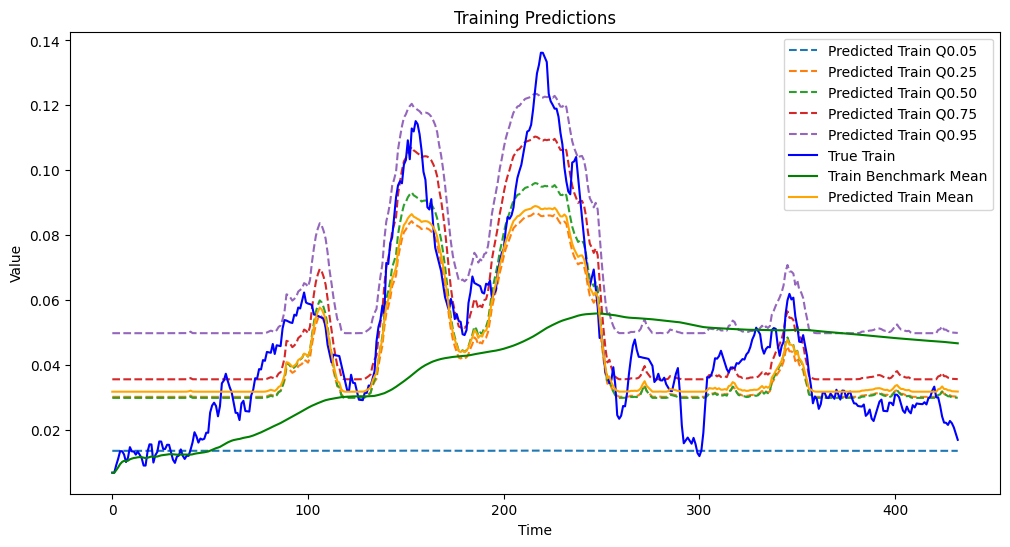

In [77]:
# plot the training predictions with the training quantiles
# train_mean_preds = np.array([0.15,0.225,0.25,0.225,0.15]) @ train_preds.transpose()
plt.figure(figsize=(12, 6))
for i, q in enumerate(quantiles):
    plt.plot(train_preds[:, i], label=f'Predicted Train Q{q:.2f}', linestyle='--')
plt.plot(y_train_full_rnn[:, 0], label='True Train', color='blue')
plt.plot(train_benchmark_mean, label='Train Benchmark Mean', color='green')
plt.plot(train_mean_preds, label='Predicted Train Mean', color='orange')
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Training Predictions')
plt.legend()
plt.show()

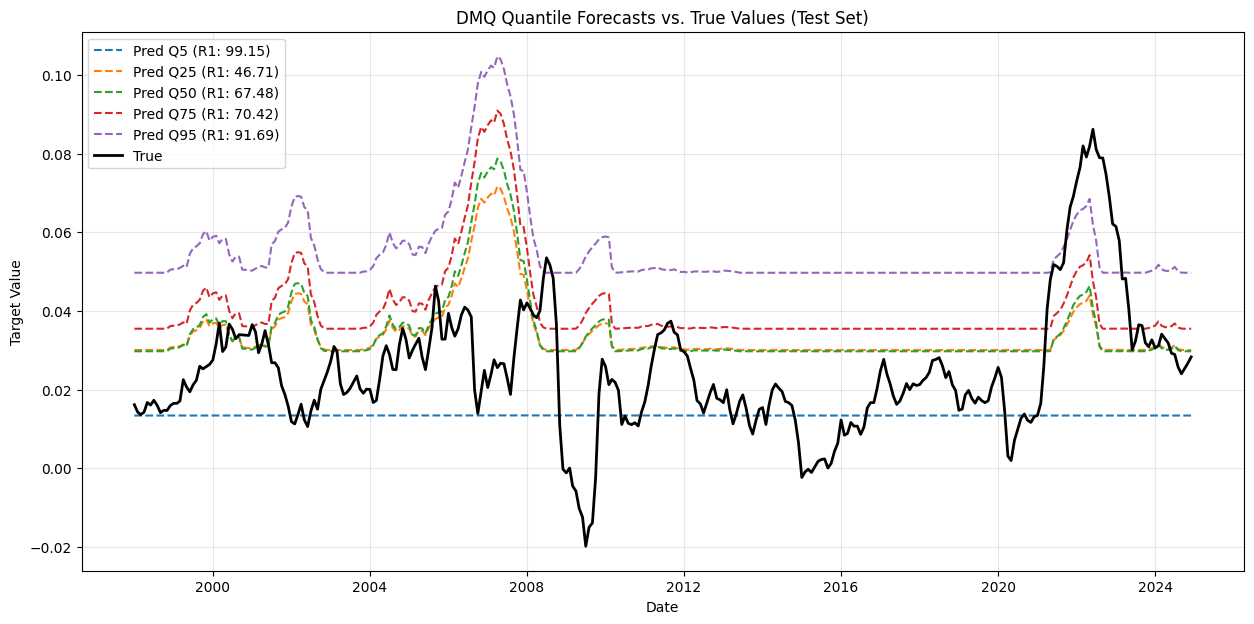

In [78]:
# Plot the results
plt.figure(figsize=(15, 7))
test_dates = pd.date_range(start=meta_data['test_start'], end='2024-12-01', freq='MS')

for i, q in enumerate(quantiles):
    plt.plot(test_dates, test_preds[:, i], label=f'Pred Q{int(q*100)} (R1: {r1_scores[i]:.2f})', linestyle='--')

plt.plot(test_dates, full_y_series.loc[meta_data['test_start']:'2024-12-01'].values, label='True', color='black', linewidth=2)

plt.title('DMQ Quantile Forecasts vs. True Values (Test Set)')
plt.xlabel('Date')
plt.ylabel('Target Value')
plt.legend()
plt.grid(alpha=0.3)
plt.show()